# Modelos de Classificação — Sinistros de Saúde

Treinamento de modelos binários com PyCaret para prever `ClaimStatus` (Aprovado / Negado).

> **Requisito:** Apenas modelos interpretáveis (com feature importance ou coeficientes visíveis).
> Split: 70% treino / 30% teste.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
from pycaret.classification import (
    setup, compare_models, tune_model, predict_model, pull,
    plot_model, save_model, get_config,
)

DATASET_PATH = Path('../datasets/output/enhanced_claims_ptbr.csv')
MODEL_DIR    = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 1 — Carregar e Preparar Dataset

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f'Shape original: {df.shape}')
print('ClaimStatus:', df['ClaimStatus'].value_counts().to_dict())

DROP_COLS = [
    'ClaimID', 'PatientID', 'ProviderID',
    'ClaimDate',
    'ClaimAmountBRL',
    'PatientIncomeBRL',
    'DiagnosisNamePTBR',
    'ProcedureNamePTBR',
    'ProviderLocation',
    'ProviderStateName',
]
df = df.drop(columns=DROP_COLS)
df['IsHomeOwner']         = df['IsHomeOwner'].astype(int)
df['HasChronicCondition'] = df['HasChronicCondition'].astype(int)

# Feature engineering: ratios e interações que as regras de negócio usam diretamente
df['ClaimToIncomeRatio']   = (df['ClaimAmountUSD'] / df['PatientIncomeUSD'].clip(lower=1)).round(4)
df['IsLongTermInsured']    = (df['YearsAsInsured'] >= 8).astype(int)
df['IsNewInsured']         = (df['YearsAsInsured'] <= 2).astype(int)
df['IsHighValueClaim']     = (df['ClaimAmountUSD'] > df['ClaimAmountUSD'].quantile(0.75)).astype(int)
df['IsElderly']            = (df['PatientAge'] > 60).astype(int)

print(f'Shape após feature engineering: {df.shape}')
print(f'Features ({len(df.columns)}): {df.columns.tolist()}')

Shape original: (4500, 29)
ClaimStatus: {'Aprovado': 3114, 'Negado': 1386}
Shape após feature engineering: (4500, 24)
Features (24): ['ClaimAmountUSD', 'DiagnosisCode', 'ProcedureCode', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'ClaimType', 'ClaimSubmissionMethod', 'PatientIncomeUSD', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderState', 'ChildrenCount', 'IsHomeOwner', 'EducationLevel', 'PlanType', 'YearsAsInsured', 'HasChronicCondition', 'ClaimToIncomeRatio', 'IsLongTermInsured', 'IsNewInsured', 'IsHighValueClaim', 'IsElderly']


## 2 — Setup PyCaret (70/30 split)

In [3]:
clf = setup(
    data             = df,
    target           = 'ClaimStatus',
    train_size       = 0.7,
    session_id       = 42,
    normalize        = True,
    normalize_method = 'zscore',
    fix_imbalance    = False,  # SMOTE prejudica modelos em árvore neste dataset
    verbose          = False,
)

n_train = get_config('X_train').shape[0]
n_test  = get_config('X_test').shape[0]
print(f'Treino : {n_train} amostras ({n_train/(n_train+n_test)*100:.0f}%)')
print(f'Teste  : {n_test}  amostras ({n_test/(n_train+n_test)*100:.0f}%)')

Treino : 3150 amostras (70%)
Teste  : 1350  amostras (30%)


## 3 — Comparar Modelos Interpretáveis

Apenas modelos que expõem **feature importance** ou **coeficientes** diretamente:

| ID | Modelo | Peso/importância |
|---|---|---|
| `lr` | Logistic Regression | coeficientes |
| `ridge` | Ridge Classifier | coeficientes |
| `dt` | Decision Tree | feature importance (Gini) |
| `rf` | Random Forest | feature importance (média) |
| `et` | Extra Trees | feature importance (média) |
| `ada` | AdaBoost | feature importance |
| `gbc` | Gradient Boosting | feature importance |
| `xgboost` | XGBoost | feature importance (gain) |
| `lightgbm` | LightGBM | feature importance (gain) |

In [4]:
INTERPRETABLE = ['lr', 'ridge', 'dt', 'rf', 'et', 'ada', 'gbc', 'xgboost', 'lightgbm']

top5 = compare_models(
    include          = INTERPRETABLE,
    sort             = 'Accuracy',
    n_select         = 5,
    cross_validation = True,
    fold             = 5,
    verbose          = True,
)

comparison = pull()
print('\nTop 5 modelos (parâmetros default):')
for i, m in enumerate(top5):
    print(f'  {i+1}. {type(m).__name__}')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9213,0.9771,0.9213,0.9210,0.9208,0.8134,0.8140,0.1540
lr,Logistic Regression,0.9114,0.9732,0.9114,0.9112,0.9111,0.7907,0.7912,1.2960
xgboost,Extreme Gradient Boosting,0.9029,0.9668,0.9029,0.9024,0.9019,0.7678,0.7694,0.1340
gbc,Gradient Boosting Classifier,0.8994,0.9697,0.8994,0.8992,0.8970,0.7542,0.7589,0.3520
ridge,Ridge Classifier,0.8987,0.9655,0.8987,0.8985,0.8981,0.7597,0.7608,0.3480
lightgbm,Light Gradient Boosting Machine,0.8981,0.9653,0.8981,0.8974,0.8967,0.7551,0.7572,0.4560
et,Extra Trees Classifier,0.8810,0.9537,0.8810,0.8811,0.8776,0.7071,0.7141,0.1620
rf,Random Forest Classifier,0.8727,0.9521,0.8727,0.8734,0.8681,0.6833,0.6931,0.5240
dt,Decision Tree Classifier,0.8063,0.7697,0.8063,0.8054,0.8056,0.5426,0.5429,0.0920



Top 5 modelos (parâmetros default):
  1. AdaBoostClassifier
  2. LogisticRegression
  3. XGBClassifier
  4. GradientBoostingClassifier
  5. RidgeClassifier


## 4 — Otimização de Hiperparâmetros (Random Search)

PyCaret `tune_model` com `search_algorithm='random'` — **50 iterações por modelo**, otimizando Accuracy via cross-validation 5-fold nos **top-5 modelos** do compare.

In [5]:
# Tunar os 5 melhores com Random Search (50 iterações cada)
tuning_results = []

for i, model in enumerate(top5):
    name = type(model).__name__
    print(f'[{i+1}/5] Tunando {name}...')
    try:
        tuned = tune_model(
            model,
            n_iter           = 50,
            optimize         = 'Accuracy',
            search_library   = 'scikit-learn',
            search_algorithm = 'random',
            fold             = 5,
            verbose          = False,
            return_train_score = False,
        )
        metrics = pull()
        cv_acc = float(metrics['Accuracy'].mean())
        tuning_results.append({'name': name, 'model': tuned, 'cv_accuracy': cv_acc})
        print(f'       CV Accuracy: {cv_acc:.4f}')
    except Exception as e:
        print(f'       Erro: {e}')

tuning_results.sort(key=lambda x: x['cv_accuracy'], reverse=True)

print('\n── Ranking pós Random Search (CV) ──')
for r in tuning_results:
    print(f"  {r['name']:35s} {r['cv_accuracy']:.4f}")

[1/5] Tunando AdaBoostClassifier...
       CV Accuracy: 0.7910
[2/5] Tunando LogisticRegression...
       CV Accuracy: 0.7840
[3/5] Tunando XGBClassifier...
       CV Accuracy: 0.7777
[4/5] Tunando GradientBoostingClassifier...
       CV Accuracy: 0.7886
[5/5] Tunando RidgeClassifier...
       CV Accuracy: 0.7729

── Ranking pós Random Search (CV) ──
  AdaBoostClassifier                  0.7910
  GradientBoostingClassifier          0.7886
  LogisticRegression                  0.7840
  XGBClassifier                       0.7777
  RidgeClassifier                     0.7729


## 5 — Avaliação no Conjunto de Teste (30%)

In [6]:
# Avaliar todos os modelos tunados no test set (30%) e escolher o melhor
print('── Avaliação no test set (30%) ──\n')

test_results = []
for r in tuning_results:
    preds   = predict_model(r['model'])
    metrics = pull()
    acc     = float(metrics['Accuracy'].iloc[0])
    test_results.append({'name': r['name'], 'model': r['model'], 'test_accuracy': acc})
    print(f"  {r['name']:35s}  Test Accuracy: {acc:.4f}")

test_results.sort(key=lambda x: x['test_accuracy'], reverse=True)

best_tuned = test_results[0]['model']
best_name  = test_results[0]['name']
best_acc   = test_results[0]['test_accuracy']

print(f'\n✓ Melhor modelo: {best_name}')
print(f'  Test Accuracy : {best_acc:.4f}  ({best_acc*100:.2f}%)')

── Avaliação no test set (30%) ──



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9289,0.9828,0.9289,0.9285,0.9286,0.8321,0.8322


  AdaBoostClassifier                   Test Accuracy: 0.9289


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9230,0.9803,0.9230,0.9223,0.9224,0.8166,0.8173


  GradientBoostingClassifier           Test Accuracy: 0.9230


...

  LogisticRegression                   Test Accuracy: 0.9333


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9022,0.9714,0.9022,0.9058,0.9033,0.7761,0.7775


  XGBClassifier                        Test Accuracy: 0.9022


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9252,0,0.9252,0.9247,0.9243,0.8206,0.8220


  RidgeClassifier                      Test Accuracy: 0.9252

✓ Melhor modelo: LogisticRegression
  Test Accuracy : 0.9333  (93.33%)


## 6 — Importância das Features

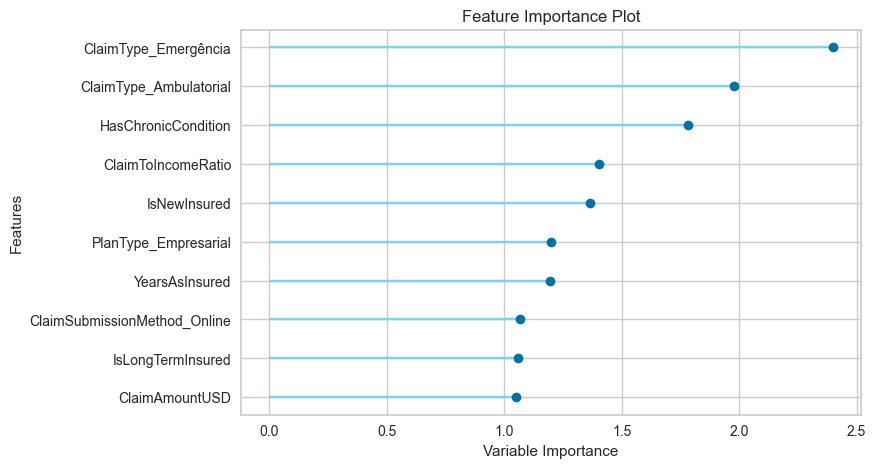

In [7]:
plot_model(best_tuned, plot='feature', display_format=None)

## 7 — Matriz de Confusão

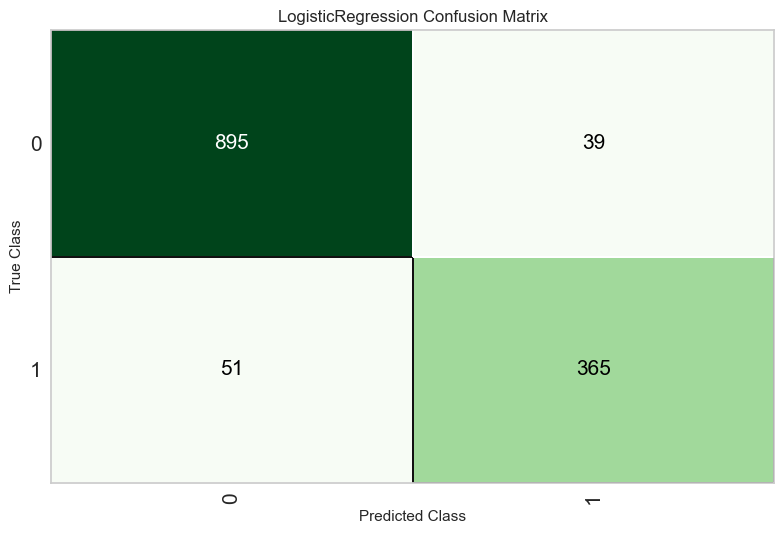

In [8]:
plot_model(best_tuned, plot='confusion_matrix', display_format=None)

## 8 — Salvar Melhor Modelo

In [9]:
model_path = MODEL_DIR / 'best_model'
save_model(best_tuned, str(model_path))

print(f'Modelo salvo em : {model_path.resolve()}.pkl')
print(f'Tipo            : {best_name}')
print(f'Test Accuracy   : {best_acc:.4f}  ({best_acc*100:.2f}%)')

Transformation Pipeline and Model Successfully Saved
Modelo salvo em : /Users/pedrocunha/Projects/Personal/ai-operador-medico/ai/models/best_model.pkl
Tipo            : LogisticRegression
Test Accuracy   : 0.9333  (93.33%)
